In [1]:
!pip install -q kaggle scikit-learn opencv-python-headless torch torchvision

import os, zipfile, glob, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import torch
import torchvision
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TF:', tf.__version__, ' Torch:', torch.__version__, ' Device:', device)

TF: 2.20.0  Torch: 2.11.0+cu128  Device: cuda


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_84d3e62d900a5c3e9ab9eedc85c84684'

In [3]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p /content/data

import zipfile
with zipfile.ZipFile('/content/data/breast-ultrasound-images-dataset.zip', 'r') as z:
    z.extractall('/content/data')

DATA_ROOT = '/content/data/Dataset_BUSI_with_GT'
print(os.listdir(DATA_ROOT))

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:13<00:00, 15.4MB/s]

['normal', 'malignant', 'benign']


In [4]:
IMG_SIZE = 256

def collect_pairs(class_name):
    pairs = []
    all_pngs = sorted(glob.glob(f'{DATA_ROOT}/{class_name}/*.png'))
    base_images = [p for p in all_pngs if '_mask' not in p]
    for img_path in base_images:
        stem = img_path.replace('.png', '')
        mask_paths = sorted(glob.glob(f'{stem}_mask*.png'))
        if mask_paths:
            pairs.append((img_path, mask_paths))
    return pairs

benign_pairs = [(p, m, 0) for p, m in collect_pairs('benign')]
malignant_pairs = [(p, m, 1) for p, m in collect_pairs('malignant')]
pairs = benign_pairs + malignant_pairs
print('Total image/mask pairs:', len(pairs))

Total image/mask pairs: 647


In [5]:
def load_pair(img_path, mask_paths, size=IMG_SIZE):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size))
    img_norm = img.astype('float32') / 255.0

    mask = np.zeros((size, size), dtype='float32')
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (size, size))
        mask = np.maximum(mask, (m > 127).astype('float32'))

    return img, img_norm, mask

imgs_raw, imgs_norm, masks, labels = [], [], [], []
for img_path, mask_paths, label in pairs:
    raw, norm, mask = load_pair(img_path, mask_paths)
    imgs_raw.append(raw)
    imgs_norm.append(norm)
    masks.append(mask)
    labels.append(label)

imgs_raw = np.array(imgs_raw)
imgs_norm = np.array(imgs_norm)[..., np.newaxis]
masks = np.array(masks)[..., np.newaxis]
labels = np.array(labels)

idx_all = np.arange(len(pairs))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.3, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=labels[idx_temp])

print('Train:', len(idx_train), ' Val:', len(idx_val), ' Test:', len(idx_test))

Train: 452  Val: 97  Test: 98


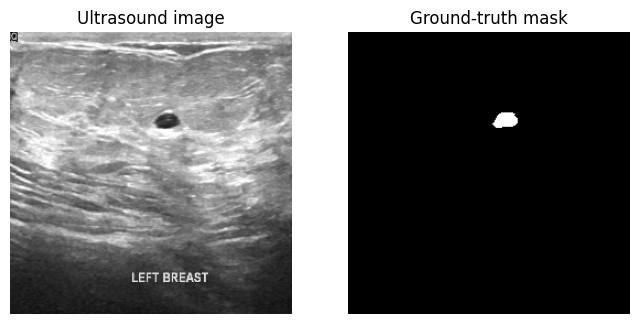

In [6]:
sample_i = 0
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(imgs_raw[sample_i], cmap='gray'); ax[0].set_title('Ultrasound image'); ax[0].axis('off')
ax[1].imshow(masks[sample_i, ..., 0], cmap='gray'); ax[1].set_title('Ground-truth mask'); ax[1].axis('off')
plt.show()

In [7]:
def otsu_mask(img_uint8):
    blur = cv2.GaussianBlur(img_uint8, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return (mask > 0).astype('float32')

def kmeans_mask(img_uint8, k=3):
    pixels = img_uint8.reshape(-1, 1).astype('float32')
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels_km, centers = cv2.kmeans(pixels, k, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)
    darkest_cluster = np.argmin(centers)
    seg = (labels_km.flatten() == darkest_cluster).astype('float32')
    return seg.reshape(img_uint8.shape)

def dice_score(gt, pred, smooth=1e-6):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    inter = np.sum(gt * pred)
    return (2 * inter + smooth) / (np.sum(gt) + np.sum(pred) + smooth)

results_table = {}
demo_idx = list(idx_test[:6])

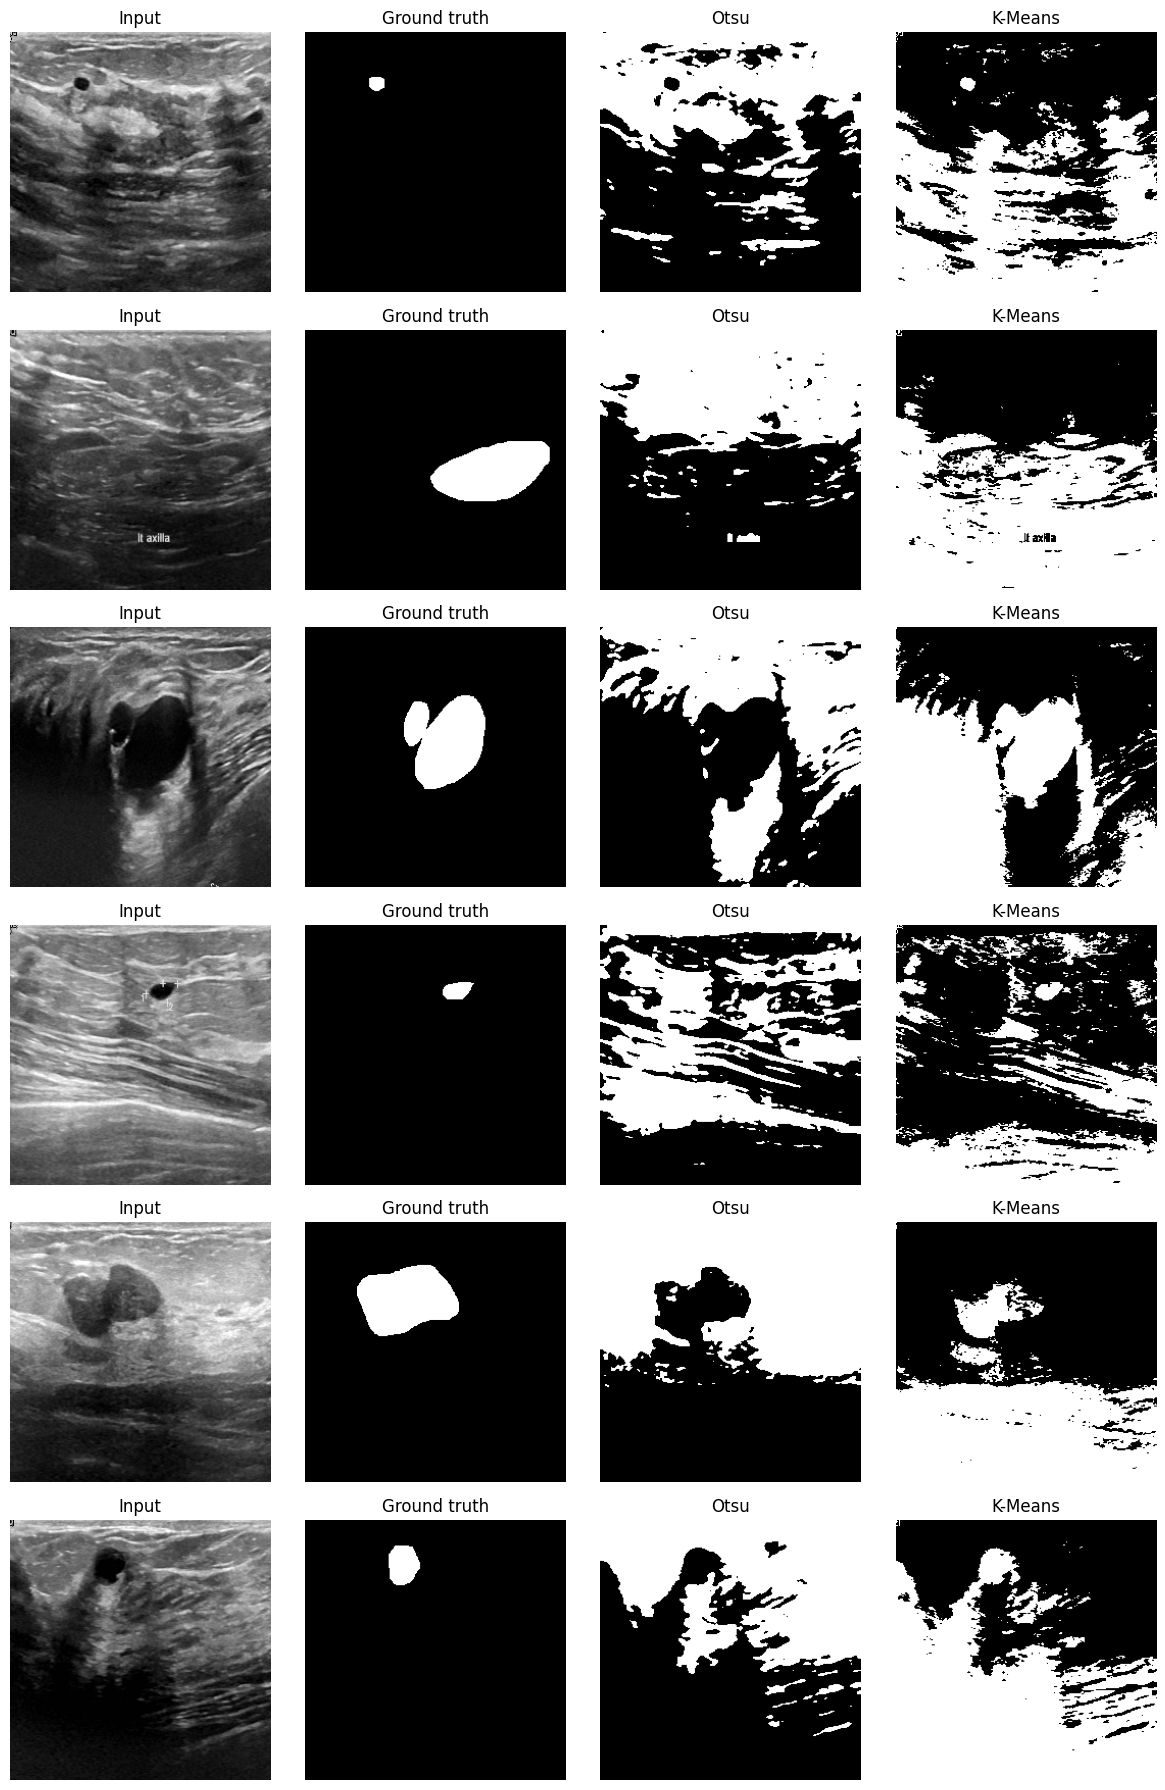

Otsu mean Dice: 0.015410926
K-Means mean Dice: 0.12095642


In [8]:
otsu_dices, km_dices = [], []
fig, axes = plt.subplots(len(demo_idx), 4, figsize=(12, 3 * len(demo_idx)))
for row, i in enumerate(demo_idx):
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    om = otsu_mask(img_u8)
    km = kmeans_mask(img_u8)
    otsu_dices.append(dice_score(gt, om))
    km_dices.append(dice_score(gt, km))

    axes[row, 0].imshow(img_u8, cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(om, cmap='gray'); axes[row, 2].set_title('Otsu'); axes[row, 2].axis('off')
    axes[row, 3].imshow(km, cmap='gray'); axes[row, 3].set_title('K-Means'); axes[row, 3].axis('off')
plt.tight_layout(); plt.show()

results_table['Otsu thresholding'] = np.mean(otsu_dices)
results_table['K-Means'] = np.mean(km_dices)
print('Otsu mean Dice:', np.mean(otsu_dices))
print('K-Means mean Dice:', np.mean(km_dices))

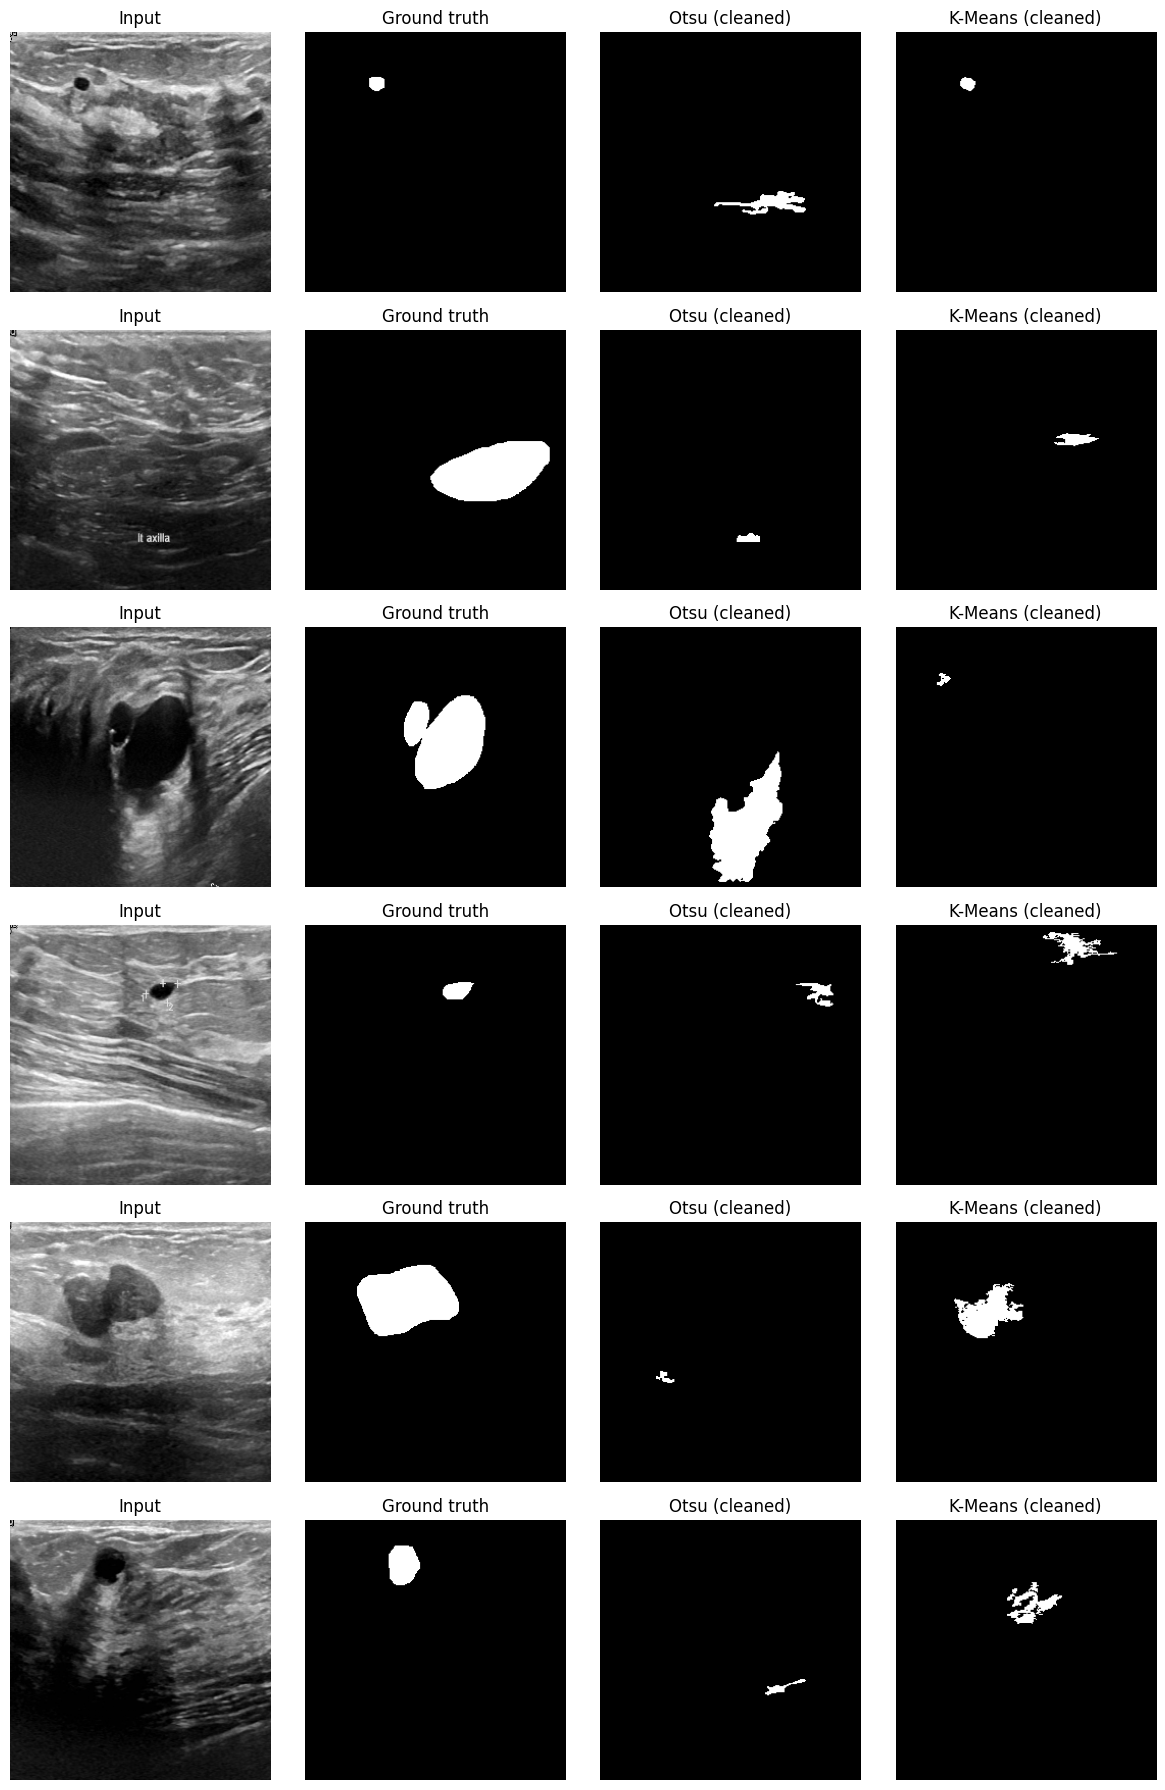

Otsu mean Dice (cleaned): 0.00016567325
K-Means mean Dice (cleaned): 0.23819746


In [9]:
def clean_mask(binary_mask):
    binary_mask = (binary_mask * 255).astype('uint8')
    n_labels, labels_cc, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    h, w = binary_mask.shape
    best_label, best_area = 0, 0
    for lbl in range(1, n_labels):
        x, y, bw, bh, area = stats[lbl]
        touches_border = (x == 0 or y == 0 or x + bw == w or y + bh == h)
        if not touches_border and area > best_area:
            best_area = area
            best_label = lbl
    return (labels_cc == best_label).astype('float32') if best_label > 0 else np.zeros_like(binary_mask, dtype='float32')

otsu_dices2, km_dices2 = [], []
fig, axes = plt.subplots(len(demo_idx), 4, figsize=(12, 3 * len(demo_idx)))
for row, i in enumerate(demo_idx):
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    om = clean_mask(otsu_mask(img_u8))
    km = clean_mask(kmeans_mask(img_u8))
    otsu_dices2.append(dice_score(gt, om))
    km_dices2.append(dice_score(gt, km))

    axes[row, 0].imshow(img_u8, cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(om, cmap='gray'); axes[row, 2].set_title('Otsu (cleaned)'); axes[row, 2].axis('off')
    axes[row, 3].imshow(km, cmap='gray'); axes[row, 3].set_title('K-Means (cleaned)'); axes[row, 3].axis('off')
plt.tight_layout(); plt.show()

results_table['Otsu thresholding'] = np.mean(otsu_dices2)
results_table['K-Means'] = np.mean(km_dices2)
print('Otsu mean Dice (cleaned):', np.mean(otsu_dices2))
print('K-Means mean Dice (cleaned):', np.mean(km_dices2))

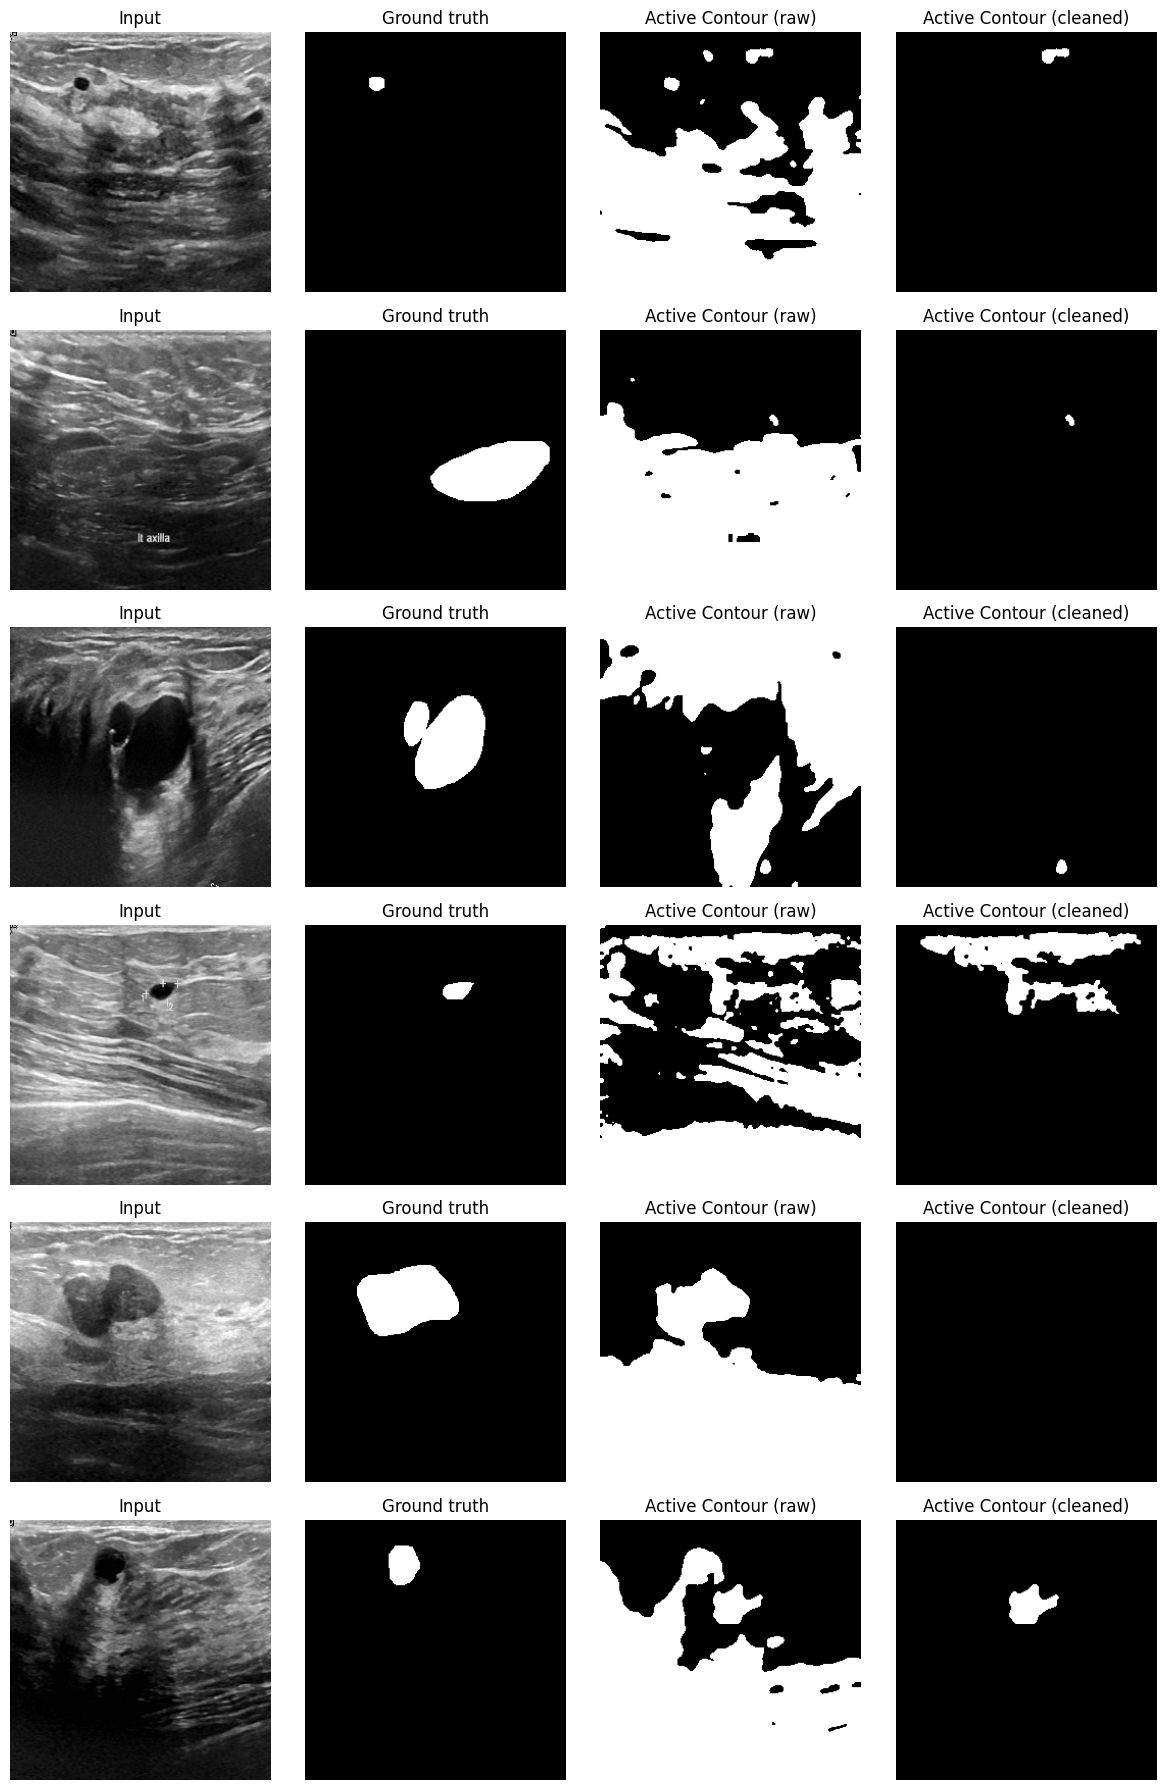

Active Contour mean Dice: 0.017526733


In [10]:
!pip install -q scikit-image
from skimage.segmentation import chan_vese

def active_contour_mask(img_uint8):
    img_float = img_uint8.astype('float64') / 255.0
    cv = chan_vese(img_float, mu=0.25, lambda1=1, lambda2=1,
                    tol=1e-3, max_num_iter=200, dt=0.5,
                    init_level_set="checkerboard", extended_output=False)
    return cv.astype('float32')

ac_dices = []
fig, axes = plt.subplots(len(demo_idx), 4, figsize=(12, 3 * len(demo_idx)))
for row, i in enumerate(demo_idx):
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]
    ac = clean_mask(active_contour_mask(img_u8))
    ac_dices.append(dice_score(gt, ac))

    axes[row, 0].imshow(img_u8, cmap='gray'); axes[row, 0].set_title('Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(gt, cmap='gray'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(active_contour_mask(img_u8), cmap='gray'); axes[row, 2].set_title('Active Contour (raw)'); axes[row, 2].axis('off')
    axes[row, 3].imshow(ac, cmap='gray'); axes[row, 3].set_title('Active Contour (cleaned)'); axes[row, 3].axis('off')
plt.tight_layout(); plt.show()

results_table['Active Contour'] = np.mean(ac_dices)
print('Active Contour mean Dice:', np.mean(ac_dices))

In [11]:
import numpy as np

In [12]:
demo_idx = np.random.choice(len(imgs_raw), size=5, replace=False)  # or however many demo samples you want

In [13]:
def pixel_accuracy(gt, pred):
    gt = (gt > 0.5).astype('float32').flatten()
    pred = (pred > 0.5).astype('float32').flatten()
    correct = np.sum(gt == pred)
    return correct / len(gt)

otsu_dices, otsu_accs = [], []
km_dices, km_accs = [], []
ac_dices, ac_accs = [], []

for i in demo_idx:
    img_u8 = imgs_raw[i]
    gt = masks[i, ..., 0]

    om = clean_mask(otsu_mask(img_u8))
    km = clean_mask(kmeans_mask(img_u8))
    ac = clean_mask(active_contour_mask(img_u8))

    otsu_dices.append(dice_score(gt, om)); otsu_accs.append(pixel_accuracy(gt, om))
    km_dices.append(dice_score(gt, km));   km_accs.append(pixel_accuracy(gt, km))
    ac_dices.append(dice_score(gt, ac));   ac_accs.append(pixel_accuracy(gt, ac))

print(f"{'Technique':<20}{'Mean Dice':>15}{'Mean Accuracy':>18}")
print('-' * 53)
print(f"{'Otsu':<20}{np.mean(otsu_dices):>15.4f}{np.mean(otsu_accs):>18.4f}")
print(f"{'K-Means':<20}{np.mean(km_dices):>15.4f}{np.mean(km_accs):>18.4f}")
print(f"{'Active Contour':<20}{np.mean(ac_dices):>15.4f}{np.mean(ac_accs):>18.4f}")

Technique                 Mean Dice     Mean Accuracy
-----------------------------------------------------
Otsu                         0.0007            0.8715
K-Means                      0.0006            0.8780
Active Contour               0.0000            0.8699
